## HW 9

In [41]:
import gymnasium as gym
import numpy as np

In [42]:
# Initialize environment 
env = gym.make('FrozenLake-v1', is_slippery=True)
n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"States: {n_states}")
print(f"Actions: {n_actions}")

States: 16
Actions: 4


In [43]:
# Value Func
def compute_value_function(env, policy, gamma=0.99, theta=1e-6):
    value_table = np.zeros(env.observation_space.n)

    while True:
        delta = 0

        # Evaluate every state on the grid
        for state in range(env.observation_space.n):
            v = 0
            action = policy[state]

            # Calc the expected value 
            for prob, next_state, reward, done in env.unwrapped.P[state][action]:
                v += prob * (reward + gamma * value_table[next_state])

            # The maximum change to check 
            delta = max(delta, abs(value_table[state] - v))
            value_table[state] = v

        if delta < theta:
            break

    return value_table

In [44]:
# Test (all zeros)
random_policy = np.zeros(env.observation_space.n, dtype=int)
value_function = compute_value_function(env, random_policy)

print("Value function for random policy:")
print(value_function)

Value function for random policy:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [45]:
# Policy
def extract_policy(env, value_table, gamma=0.99):
    policy = np.zeros(env.observation_space.n, dtype=int)

    for state in range(env.observation_space.n):
        q_values = np.zeros(env.action_space.n)

        for action in range(env.action_space.n):
            for prob, next_state, reward, done in env.unwrapped.P[state][action]:
                q_values[action] += prob * (reward + gamma * value_table[next_state])

        # Pick the action with the highest expected value
        policy[state] = np.argmax(q_values)

    return policy


def policy_iteration(env, gamma=0.99, theta=1e-6):
    policy = np.zeros(env.observation_space.n, dtype=int)

    while True:
        old_policy = np.copy(policy)

        # 1. Evaluate the draft policy
        value_function = compute_value_function(env, policy, gamma, theta)
        
        # 2. Extract a better policy
        policy = extract_policy(env, value_function, gamma)

        # 3. Stop if the policy stops changing
        if np.array_equal(old_policy, policy):
            break

    return policy, value_function

In [46]:
# Test Policy 
optimal_policy, optimal_value_function = policy_iteration(env)

print("Optimal policy:")
print(optimal_policy)

print("\nValue function:")
print(optimal_value_function)

Optimal policy:
[0 3 3 3 0 0 0 0 3 1 0 0 0 2 1 0]

Value function:
[0.54201383 0.49878715 0.47067694 0.45683158 0.55844021 0.
 0.35833998 0.         0.59178998 0.64307352 0.61520205 0.
 0.         0.7417161  0.86283524 0.        ]


In [47]:
import matplotlib.pyplot as plt

def show_render(img):
    plt.imshow(img)
    plt.axis('off')
    plt.show()

#  Simulate an episode
def run_optimal_policy(env, policy, max_steps=20):
    reset_result = env.reset()
    
    # Handle different versions 
    state = reset_result[0] if isinstance(reset_result, tuple) else reset_result

    show_render(env.render())

    for _ in range(max_steps):
        action = policy[state]
        step_result = env.step(action)

        # Unpack the step resul
        if len(step_result) == 5:
            state, reward, terminated, truncated, info = step_result
            done = terminated or truncated
        else:
            state, reward, done, info = step_result

        show_render(env.render())

        if done:
            if reward == 1.0:
                print("Success! Reached the goal.")
            else:
                print("Failed! Fell into a hole.")
            break

Simulating the optimal policy run


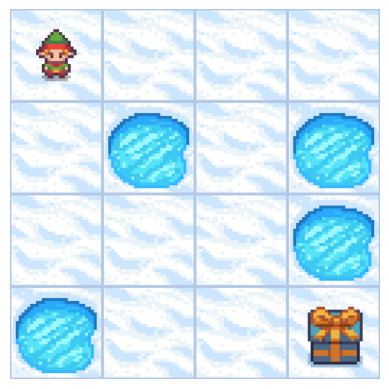

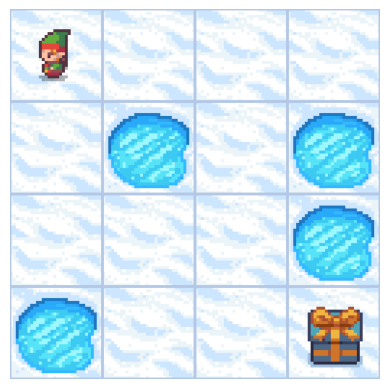

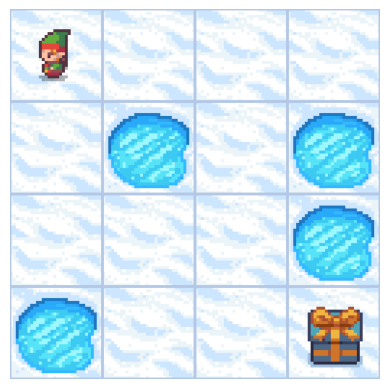

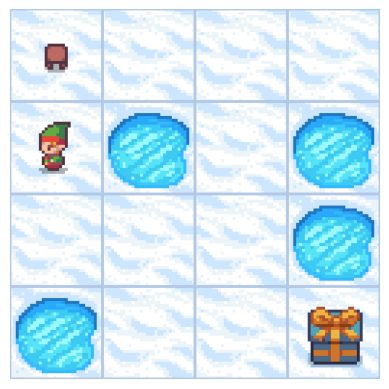

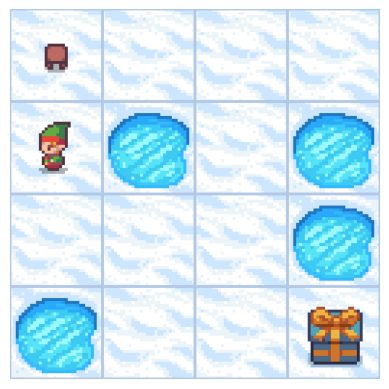

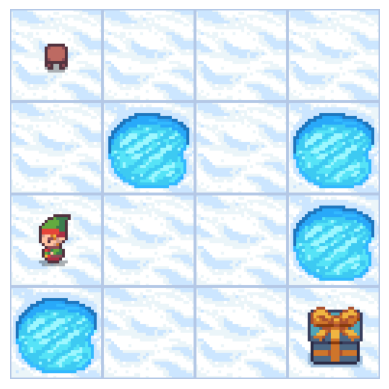

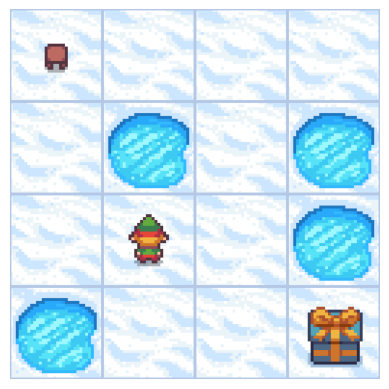

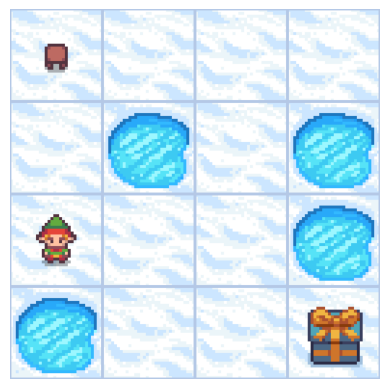

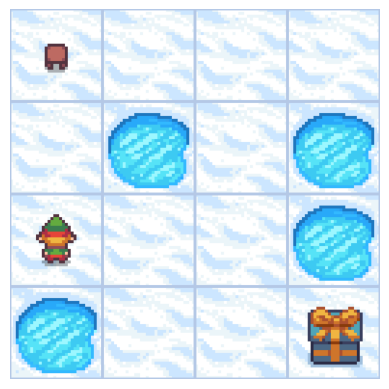

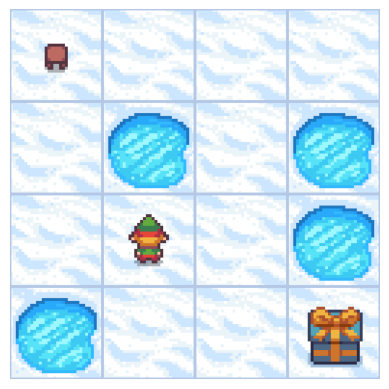

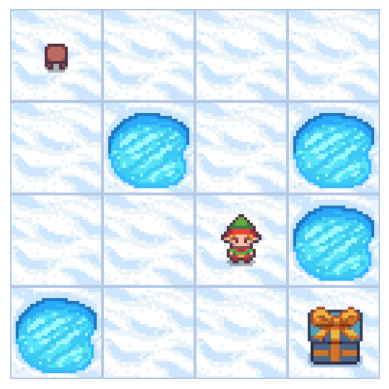

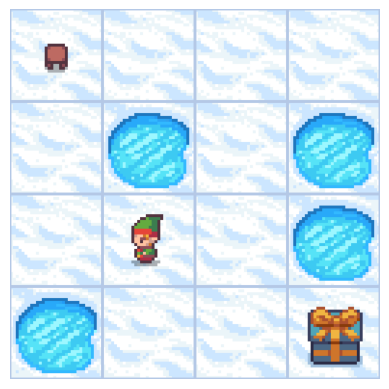

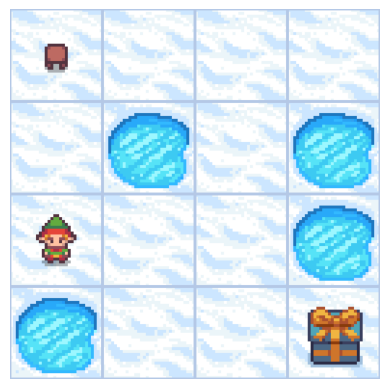

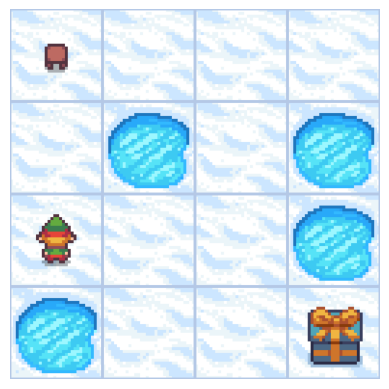

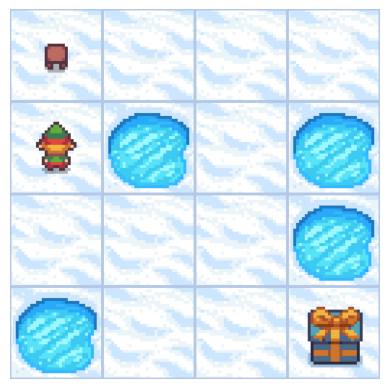

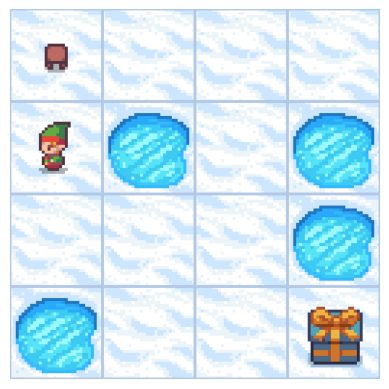

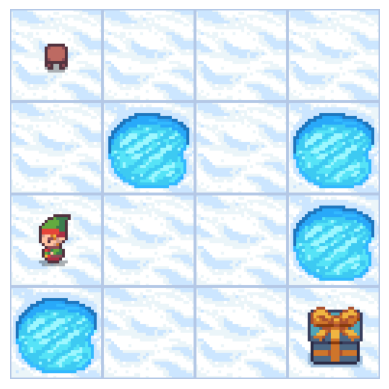

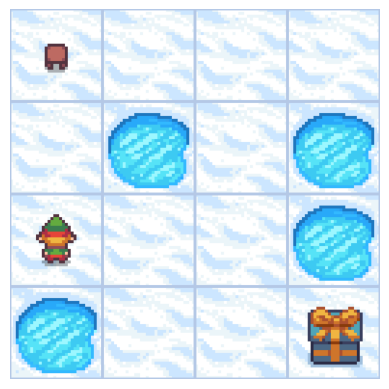

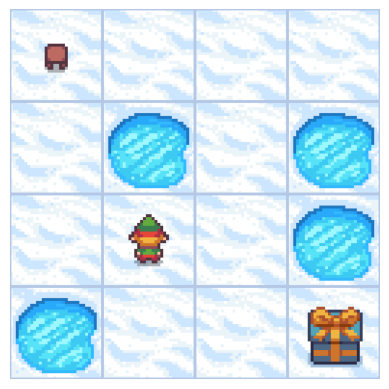

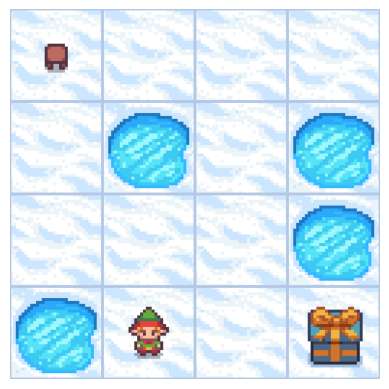

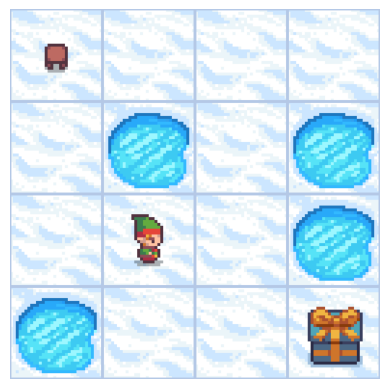

In [48]:
env_render = gym.make('FrozenLake-v1', is_slippery=True, render_mode='rgb_array')

print("Simulating the optimal policy run")
run_optimal_policy(env_render, optimal_policy)

### Conclusions

1. **Algorithm Implementation:** MDP was successfully implemented to solve the `FrozenLake-v1` environment using the `gymnasium` library. 
2. **Performance & Stochasticity:** The agent efficiently found the optimal policy. Because the environment is stochastic (`is_slippery=True`), the resulting policy avoids dangerous paths and prioritizes safer routes to reach the goal.